In [1]:
import rush_hour_rl as rl
import rush_hour_lib as lib
import random
import torch


In [2]:
DIST = 10

In [ ]:
# lib.sample_puzzles("data/rush_nw_training.txt", min_distance=DIST, max_distance=DIST, num=100)

In [4]:
puzzles = lib.read_puzzles("data/rush_nw_training.txt")

## Apprentice/teacher (ExIt) model, plain behavior cloning

Trains via `train_policy_bc` (supervised imitation of AND-OR: one batch of solve attempts, one training pass) rather than DQN. `PolicyAgent` is policy-only (no value head) and its greedy rollout uses `policy_avoiding_cycles`: it ranks legal actions by logit and falls back to the next-best one whenever the top choice would revisit an already-seen state, so a single bad decision can't strand the rollout in a 2-cycle until `max_steps` runs out. `train_policy` also applies an exponential moving average (`ema_decay`) over the trained weights across epochs, smoothing the epoch-to-epoch instability visible in `steps_history` below.</cell id="65441130">


In [5]:
train_puzzles = puzzles[DIST][:90]
test_puzzles = puzzles[DIST][90:]

In [6]:
# Seeded for reproducibility - torch.manual_seed matters as much as
# random.seed here: random.seed alone only controls AND-OR's own search,
# not PyTorch's weight init / batch shuffling, a separate source of
# run-to-run variance in whether the policy head solves independently.
random.seed(3)
torch.manual_seed(0)

trainer = rl.PuzzleTrainer(train_puzzles, test_puzzles, (6, 6))
n_examples, policy_loss, train_results, test_results, and_or_stats = trainer.train(
    n_traces=40, epochs=30, max_steps=200,
    max_examples=60000, eval_every=3,
    and_or_eval_trials=30, n_rounds=3
)
print(f"examples={n_examples}  policy_loss={policy_loss:.3f}")
print(f"train_results={train_results}")
print(f"test_results={test_results}")
print(f"and_or_stats={and_or_stats}")

training epochs: 100%|██████████| 30/30 [18:35<00:00, 37.17s/it] 


examples=60000  policy_loss=0.007
train_results=[(True, 18), (True, 46), (True, 12), (True, 65), (True, 13), (True, 18), (True, 34), (True, 14), (True, 59), (True, 19), (True, 21), (True, 14), (True, 14), (True, 25), (False, nan), (True, 46), (True, 55), (True, 20), (True, 60), (True, 47), (True, 40), (True, 31), (True, 35), (True, 27), (True, 96), (True, 21), (True, 22), (True, 47), (True, 18), (True, 149), (True, 63), (True, 68), (True, 128), (True, 12), (True, 30), (True, 97), (True, 34), (False, nan), (True, 22), (True, 140), (True, 56), (True, 50), (True, 108), (True, 143), (True, 23), (True, 20), (True, 27), (True, 30), (True, 30), (True, 31), (True, 62), (True, 54), (True, 22), (True, 111), (True, 28), (True, 10), (True, 106), (True, 36), (True, 33), (True, 36), (True, 24), (True, 32), (True, 106), (True, 16), (True, 67), (True, 53), (True, 50), (True, 55), (True, 41), (True, 42), (True, 38), (False, nan), (True, 28), (True, 47), (True, 72), (True, 47), (True, 55), (True, 20), (

In [7]:
import os
os.makedirs("models", exist_ok=True)
trainer.agent.save("models/policy_agent.pt")

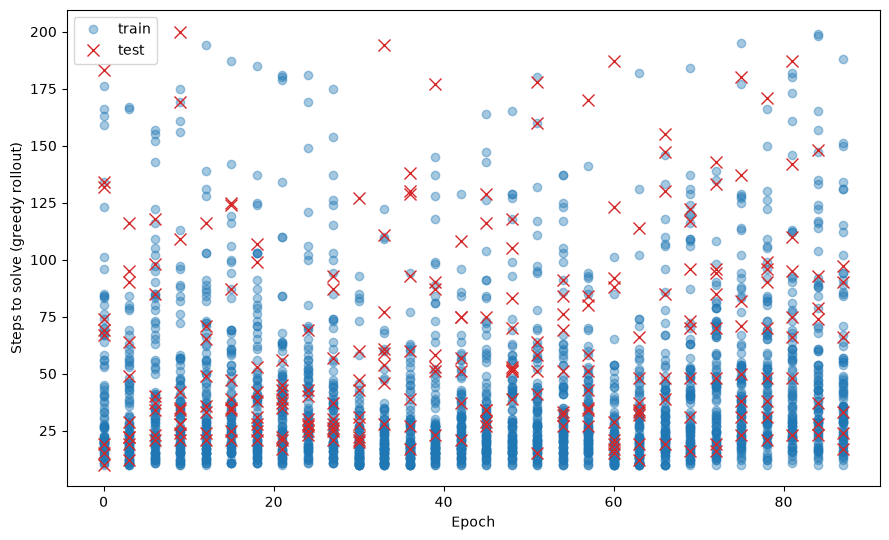

In [8]:
import matplotlib.pyplot as plt

epochs = [e for e, _, _ in trainer.history]

plt.figure(figsize=(9, 5.5))
# linestyle="None": these are isolated solved/unsolved checkpoints, not a
# continuous quantity - a connecting line would draw a straight (and
# misleading) segment across epochs that didn't solve (nan) in between.
for i in range(len(train_puzzles)):
    steps = [train_i[i][1] for _, train_i, _ in trainer.history]
    plt.plot(epochs, steps, marker="o", linestyle="None", color="tab:blue", alpha=0.4,
              label="train" if i == 0 else None)
for i in range(len(test_puzzles)):
    steps = [test_i[i][1] for _, _, test_i in trainer.history]
    plt.plot(epochs, steps, marker="x", linestyle="None", color="tab:red", markersize=8,
              label="test" if i == 0 else None)
plt.xlabel("Epoch"); plt.ylabel("Steps to solve (greedy rollout)")
plt.legend()
plt.tight_layout()
plt.savefig("visualization/apprentice_bc.png")
plt.show()

## Fine-tuning convergence: pretrained vs. scratch

The plot above scores the pretrained agent zero-shot on each test puzzle - no gradients from the test puzzles themselves. Here instead each test puzzle gets fine-tuned on directly (via `finetune_curve`, which points a `PuzzleTrainer` at a single puzzle and runs the same heuristic-guided ExIt loop), starting once from the saved pretrained checkpoint and once from a fresh, randomly-initialized agent - to see whether the shared cross-puzzle representation lets it converge to an optimal (`DIST`-length) solution in fewer fine-tuning epochs than starting from scratch. Every test puzzle in this bucket has the same optimal length (`DIST`, by construction of `read_puzzles`), so the mean steps-to-solve from `average_curves` is directly comparable to that one reference line.</cell id="82c67c37">


In [9]:
FT_KWARGS = dict(n_traces=20, epochs=5, n_rounds=6, eval_every=1)  # 30 fine-tuning epochs/puzzle

pretrained_curves, scratch_curves = [], []
for i, puzzle in enumerate(test_puzzles):
    random.seed(100 + i); torch.manual_seed(100 + i)
    pretrained_curves.append(rl.finetune_curve(rl.PolicyAgent.load("models/policy_agent.pt"), puzzle, (6, 6), **FT_KWARGS))

    random.seed(100 + i); torch.manual_seed(100 + i)
    scratch_curves.append(rl.finetune_curve(rl.PolicyAgent((6, 6)), puzzle, (6, 6), **FT_KWARGS))

training epochs: 100%|██████████| 5/5 [00:00<00:00,  8.53it/s]


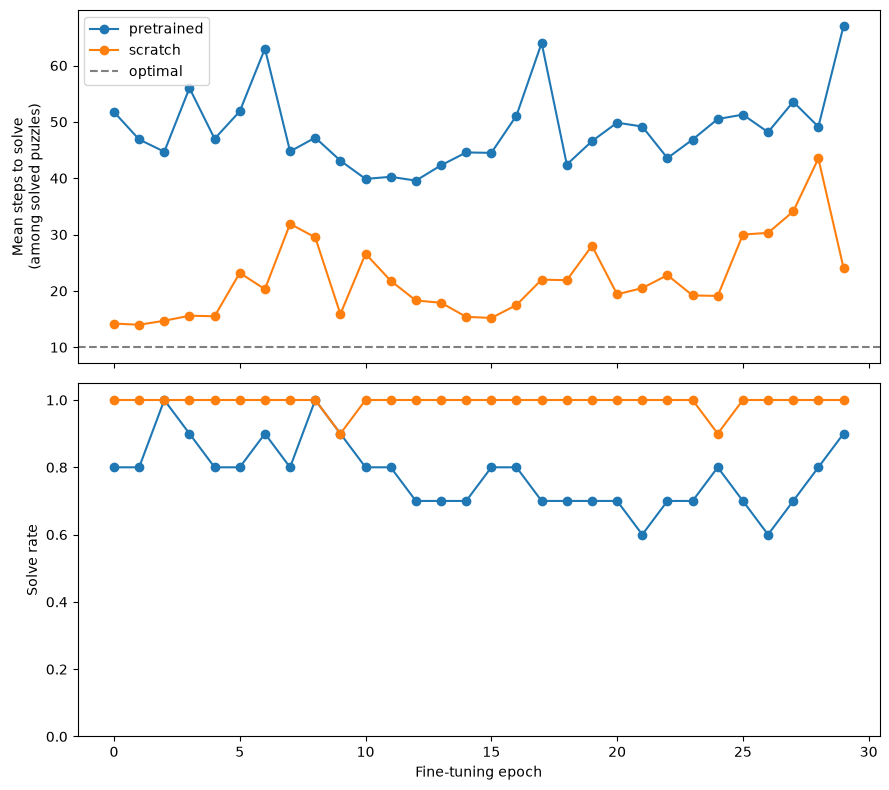

In [10]:
pre_epochs, pre_steps, pre_rate = rl.average_curves(pretrained_curves)
scr_epochs, scr_steps, scr_rate = rl.average_curves(scratch_curves)

fig, (ax_steps, ax_rate) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_steps.plot(pre_epochs, pre_steps, marker="o", color="tab:blue", label="pretrained")
ax_steps.plot(scr_epochs, scr_steps, marker="o", color="tab:orange", label="scratch")
ax_steps.axhline(DIST, color="gray", linestyle="--", label="optimal")
ax_steps.set_ylabel("Mean steps to solve\n(among solved puzzles)")
ax_steps.legend()

ax_rate.plot(pre_epochs, pre_rate, marker="o", color="tab:blue", label="pretrained")
ax_rate.plot(scr_epochs, scr_rate, marker="o", color="tab:orange", label="scratch")
ax_rate.set_ylim(0, 1.05)
ax_rate.set_xlabel("Fine-tuning epoch")
ax_rate.set_ylabel("Solve rate")

plt.tight_layout()
plt.savefig("visualization/finetune_convergence.png")
plt.show()